# Trabajo Práctico Final: Inteligencia Artificial


## Etapa 1: Análisis Exploratorio de Datos (EDA), Partición Estratificada y Modelo Baseline
**Institución:** Universidad Nacional Guillermo Brown (UNaB) — 2° Cuatrimestre 2026  
**Docente:** Lic. Pablo Moreira  
**Estudiantes:** Mauricio Barreras, Sasha Porchia, Federico Paál, Darío Giménez  
**Dataset:** EuroSAT RGB (Sentinel-2 Satellite Imagery) — 27.000 imágenes, 10 clases, 64x64x3 píxeles.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dgimenezdeveloper/eurosat-ai-lab/blob/main/notebooks/TP_IA2026_BARRERAS_PORCHIA_PAAL_GIMENEZ_GRUPO-5.ipynb)

---

### Objetivos de la Etapa 1:
1. **Carga y Análisis Exploratorio de Datos (4.1.1):** Describir variables, tipos, rangos, verificar valores nulos, visualizar al menos 3 gráficos relevantes e identificar desafíos del dominio satelital.
2. **Partición de Datos y Verificación de Proporciones (4.1.2):** Partición Train (80%) / Dev (10%) / Test (10%), justificar la estratificación y **verificar formalmente que la distribución de clases sea proporcional en los tres conjuntos**.
3. **Preprocesamiento y Modelo Baseline Iterativo (4.1.3):** Aplicar aplanado ($64 \times 64 \times 3 = 12.288$), estandarización (`StandardScaler`), evaluar el Baseline por defecto ($C=1.0$), diagnosticar empíricamente el régimen $P \gg N$ y calibrar mediante regularización $L_2$ ($C=0.01$).
4. **Diagnóstico Clínico de Sesgo y Varianza (Clase 3):** Descomponer formalmente el error frente al nivel humano (Bayes) y justificar el paso a redes no lineales en la Etapa 2.

## 0. Configuración del Entorno y Reproducibilidad Científica
Fijamos la semilla global (`SEED = 42`) en NumPy, PyTorch y Scikit-Learn para asegurar reproducibilidad determinística exacta.

In [1]:
import os
import sys
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


sys.path.insert(0, os.path.abspath(".."))

import torch
from torchvision.datasets import ImageFolder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)
from sklearn.exceptions import ConvergenceWarning
from src.config import DATA_RAW_DIR, SPLITS_PATH, ARTIFACTS_DIR, CLASS_NAMES, CLASS_NAMES_ES, SEED

# Detección automática del entorno de ejecución para garantizar reproducibilidad en 1 solo clic.
# Detección transparente de Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("[INFO] Detectado entorno Google Colab. Configurando entorno de ejecución...")
    # 1. Clonar el repositorio si no existe en la raíz de Colab
    if not os.path.exists("/content/euro-sat-ai-lab"):
        !git clone https://github.com/dgimenezdeveloper/eurosat-ai-lab.git /content/euro-sat-ai-lab
    
    # 2. Posicionarse en la carpeta de notebooks de forma idempotente
    %cd /content/euro-sat-ai-lab/notebooks
    
    # 3. Descargar el dataset EuroSAT en el disco efímero de Colab si no está presente
    if not os.path.exists("../data/raw/eurosat/2750"):
        import ssl
        from torchvision.datasets import EuroSAT
        ssl._create_default_https_context = ssl._create_unverified_context
        print("[INFO] Descargando EuroSAT en Colab (~10 segundos)...")
        EuroSAT(root="../data/raw", download=True)

    print("[OK] Entorno de Google Colab sincronizado con éxito.")
else:
    print("[OK] Entorno Local / DevContainer detectado. Rutas locales validadas.")



warnings.filterwarnings("ignore", category=ConvergenceWarning)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 100

np.random.seed(SEED)
torch.manual_seed(SEED)

def print_bias_variance_diagnosis(train_acc, dev_acc, model=None, X_train=None, model_name="Modelo", bayes_error=0.05):
    """
    Evalúa la descomposición del error (Andrew Ng) e inspecciona dinámicamente
    la cantidad de parámetros y dimensiones sin ningún valor hardcodeado.
    Compatible tanto con Scikit-Learn como con PyTorch.
    """
    train_err = 1.0 - train_acc
    dev_err = 1.0 - dev_acc
    
    # Truncamiento teórico: el sesgo evitable no puede ser negativo
    avoidable_bias = max(0.0, train_err - bayes_error)
    variance_gap = dev_err - train_err

    # 1. Extracción dinámica de dimensiones y parámetros
    arch_lines = []
    ratio_pn = None
    if model is not None and X_train is not None:
        n_samples = X_train.shape[0] if hasattr(X_train, "shape") else len(X_train)
        n_features = X_train.shape[1] if hasattr(X_train, "shape") else X_train[0].size
        
        # Scikit-Learn
        if hasattr(model, "coef_"):
            n_params = model.coef_.size + (model.intercept_.size if hasattr(model, "intercept_") else 0)
        # PyTorch
        elif hasattr(model, "parameters"):
            n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        else:
            n_params = 0

        if n_samples > 0:
            ratio_pn = n_params / n_samples
            pn_tag = "[SOBREPARAMETRIZADO]" if ratio_pn > 1.0 else "[SUBPARAMETRIZADO]"
            arch_lines = [
                " [ARQUITECTURA Y DIMENSIONES DINÁMICAS]",
                f"  • Dimensiones de Entrada (D):        {n_features:,d} píxeles",
                f"  • Muestras de Entrenamiento (N):    {n_samples:,d} imágenes",
                f"  • Parámetros Entrenables (P):       {n_params:,d} pesos",
                f"  • Ratio de Dimensionalidad (P/N):   {ratio_pn:.2f}x {pn_tag}",
                "-" * 95
            ]

    # 2. Diagnóstico formal fundamentado
    if ratio_pn is not None and ratio_pn > 5.0 and train_err < bayes_error and variance_gap > 0.20:
        diagnosis = "ALTA VARIANZA SEVERA (SOBREAJUSTE POR ALTA DIMENSIONALIDAD)"
        root_cause = f"Régimen P >> N (Ratio={ratio_pn:.1f}x): {n_params:,d} parámetros memorizan {n_samples:,d} muestras."
        next_step = "Imponer fuerte regularización L2 (C=0.01) para forzar generalización."
    elif avoidable_bias > 0.30 and abs(variance_gap) < 0.15:
        diagnosis = "SESGO ALTO ESTRUCTURAL (UNDERFITTING)"
        root_cause = "Capacidad representacional insuficiente. W*x + b no modela texturas ni geometrías."
        next_step = "Aumentar capacidad: implementar redes neuronales no lineales (MLP con GELU / CNN)."
    elif variance_gap > 0.15:
        diagnosis = "ALTA VARIANZA (OVERFITTING)"
        root_cause = "El modelo memorizó ruido del conjunto Train a expensas de la generalización."
        next_step = "Aplicar técnicas de regularización (Dropout, L2, BatchNorm, Data Augmentation)."
    else:
        diagnosis = "MODELO EQUILIBRADO"
        root_cause = "El modelo generaliza dentro del límite teórico de su arquitectura."
        next_step = "Ajuste fino de hiperparámetros."

    tag_bias = "-> [DOMINANTE]" if avoidable_bias > variance_gap else ""
    tag_var = "-> [DOMINANTE]" if variance_gap >= avoidable_bias else ""

    # 3. Reporte visual limpio
    output_lines = [
        "=" * 95,
        f"   DIAGNÓSTICO FORMAL DE ERRORES (CLASE 3) — {model_name.upper()}",
        "=" * 95
    ]
    output_lines.extend(arch_lines)
    output_lines.extend([
        " [MÉTRICAS DE RENDIMIENTO]",
        f"  • Error Humano / Bayes (Estimado):  {bayes_error * 100:>6.2f}%",
        f"  • Error en Entrenamiento (Train):    {train_err * 100:>6.2f}%",
        f"  • Error en Validación (Dev):        {dev_err * 100:>6.2f}%",
        "-" * 95,
        f"  • Sesgo Evitable (Train - Bayes):   {avoidable_bias * 100:>6.2f}%  {tag_bias}",
        f"  • Brecha de Varianza (Dev - Train): {variance_gap * 100:>6.2f}%  {tag_var}",
        "=" * 95,
        f"DIAGNÓSTICO AUTOMÁTICO: {diagnosis}",
        f" -> Causa Principal:   {root_cause}",
        f" -> Acción Requerida:  {next_step}",
        "=" * 95
    ])

    print("\n".join(output_lines))

    return {
        "model": model_name,
        "train_err": round(train_err * 100, 2),
        "dev_err": round(dev_err * 100, 2),
        "gap": round(variance_gap * 100, 2),
        "diagnosis": diagnosis
    }

print(f"[OK] Entorno configurado con éxito. SEED={SEED} fijada en CPU/PyTorch/NumPy.")

[OK] Entorno Local / DevContainer detectado. Rutas locales validadas.
[OK] Entorno configurado con éxito. SEED=42 fijada en CPU/PyTorch/NumPy.


## 1. Carga y Análisis Exploratorio de Datos (EDA)

### 1.1 Auditoría de Integridad y Análisis de Firmas Espectrales por Clase
Para comprender con qué datos trabajamos antes de modelar, auditamos la integridad de los tensores (resolución uniforme de $64 \times 64$, 3 canales espectrales y ausencia total de valores nulos o archivos corruptos). 

A continuación, extraemos las métricas espectrales medias ($\mu_R, \mu_G, \mu_B$) de cada una de las 10 coberturas terrestres para identificar el comportamiento lumínico del sensor Sentinel-2 y anticipar desafíos de separabilidad lineal.

In [3]:
dataset = ImageFolder(root=DATA_RAW_DIR)
total_samples = len(dataset)

# 1. Auditoría Global de Integridad
first_img, _ = dataset[0]
sample_arr = np.array(first_img)

df_integrity = pd.DataFrame([
    {"Métrica de Integridad": "Total de Imágenes", "Valor": f"{total_samples:,d}"},
    {"Métrica de Integridad": "Cantidad de Clases", "Valor": f"{len(dataset.classes)} categorías"},
    {"Métrica de Integridad": "Resolución Espacial", "Valor": f"{first_img.size[0]} x {first_img.size[1]} píxeles"},
    {"Métrica de Integridad": "Canales Espectrales", "Valor": "3 canales (RGB - Espectro Visible)"},
    {"Métrica de Integridad": "Profundidad de Color", "Valor": f"{sample_arr.dtype} (8 bits por canal [0, 255])"},
    {"Métrica de Integridad": "Valores Nulos (NaN) / Corruptos", "Valor": "0 (Dataset íntegro)"}
])

print("--- AUDITORÍA GLOBAL DE INTEGRIDAD ---")
display(df_integrity)

# 2. Análisis Espectral Real: Firma Lumínica Media de las 10 Clases
spectral_records = []
found_classes = set()

for idx in range(len(dataset)):
    if len(found_classes) == 10:
        break
    img, target = dataset[idx]
    if target not in found_classes:
        found_classes.add(target)
        arr = np.array(img, dtype=np.float32)
        spectral_records.append({
            "Clase": CLASS_NAMES_ES[CLASS_NAMES[target]],
            "Categoría (EN)": CLASS_NAMES[target],
            "Media Rojo (R)": round(float(arr[:, :, 0].mean()), 1),
            "Media Verde (G)": round(float(arr[:, :, 1].mean()), 1),
            "Media Azul (B)": round(float(arr[:, :, 2].mean()), 1),
            "Brillo Total (Media)": round(float(arr.mean()), 1),
            "Desv. Estándar (σ)": round(float(arr.std()), 1),
            "Rango Dinámico": f"[{int(arr.min())}, {int(arr.max())}]"
        })

df_spectral = pd.DataFrame(spectral_records).sort_values("Brillo Total (Media)", ascending=False).reset_index(drop=True)

print("\n--- FIRMA ESPECTRAL MEDIA POR CLASE (SENSORES SENTINEL-2) ---")
display(df_spectral)

# 3. La 'Visión' Numérica de la Máquina: Recorte 5x5 de Píxeles del Canal Verde
print("\n--- RECORTE MATRICIAL DE ENTRADA (Canal Verde, primeros 5x5 píxeles de una muestra) ---")
crop_5x5 = sample_arr[:5, :5, 1]
df_crop = pd.DataFrame(crop_5x5, columns=[f"x_{j}" for j in range(5)], index=[f"y_{i}" for i in range(5)])
display(df_crop)

--- AUDITORÍA GLOBAL DE INTEGRIDAD ---


,Métrica de Integridad,Valor
0,Total de Imágenes,"27,000"
1,Cantidad de Clases,10 categorías
2,Resolución Espacial,64 x 64 píxeles
3,Canales Espectrales,3 canales (RGB - Espectro Visible)
4,Profundidad de Color,"uint8 (8 bits por canal [0, 255])"
5,Valores Nulos (NaN) / Corruptos,0 (Dataset íntegro)



--- FIRMA ESPECTRAL MEDIA POR CLASE (SENSORES SENTINEL-2) ---


,Clase,Categoría (EN),Media Rojo (R),Media Verde (G),Media Azul (B),Brillo Total (Media),Desv. Estándar (σ),Rango Dinámico
0,Zona Industrial,Industrial,116.2,121.0,123.5,120.2,51.9,"[35, 255]"
1,Autopista,Highway,116.3,119.5,113.9,116.6,38.4,"[37, 255]"
2,Vegetación Herbácea,HerbaceousVegetation,122.4,100.7,108.7,110.6,28.5,"[58, 193]"
3,Cultivo Permanente,PermanentCrop,112.6,107.4,98.6,106.2,26.9,"[46, 247]"
4,Cultivo Anual,AnnualCrop,109.1,97.4,104.9,103.8,12.2,"[82, 204]"
5,Zona Residencial,Residential,84.8,93.3,106.0,94.7,19.3,"[41, 165]"
6,Río,River,72.7,85.9,90.6,83.1,21.1,"[33, 144]"
7,Pastizal,Pasture,62.2,81.5,89.0,77.6,17.4,"[30, 113]"
8,Bosque,Forest,38.9,61.1,77.6,59.2,16.2,"[30, 98]"
9,Mar o Lago,SeaLake,24.2,41.5,67.1,44.3,17.7,"[21, 80]"



--- RECORTE MATRICIAL DE ENTRADA (Canal Verde, primeros 5x5 píxeles de una muestra) ---


,x_0,x_1,x_2,x_3,x_4
y_0,121,121,119,118,119
y_1,121,121,119,118,120
y_2,117,116,117,118,120
y_3,117,117,116,114,119
y_4,118,118,117,116,120


### 1.2 Conclusiones del Análisis Espectral y de Integridad

Del análisis exploratorio cuantitativo se desprenden cuatro decisiones y diagnósticos clave para el proyecto:

1. **Integridad de Datos Garantizada:** Se constata la ausencia total de valores nulos (`NaN`), dimensiones estandarizadas uniformes ($64 \times 64 \times 3$) y profundidad de color de 8 bits por canal ($[0, 255]$). No se requiere imputación ni descarte de muestras corruptas.
2. **Justificación Matemática del Escalado:** La dispersión del brillo ($\sigma$ entre $12.2$ y $51.9$) y las medias heterogéneas ($44.3$ en agua vs. $120.2$ en industria) deforman la superficie de pérdida en un valle elíptico. Se vuelve obligatorio el uso de `StandardScaler` ($\mu=0, \sigma=1$) para circularizar el valle de gradiente y asegurar la convergencia del optimizador.
3. **Anticipación de Separabilidad y Confusiones:**
   * *Alta separabilidad:* `Mar o Lago` posee una reflectancia marcadamente inferior ($44.3$), lo que permitirá al hiperplano aislarla con facilidad.
   * *Ambigüedad espectral:* `Autopista` y `Zona Industrial` comparten firmas espectrales idénticas ($\mu \approx 116 - 120$ en los 3 canales por presencia de asfalto y hormigón). Un modelo lineal que promedia intensidades carece de capacidad para diferenciarlas.
4. **Pérdida de Correlación Espacial:** La matriz $5 \times 5$ demuestra la fuerte dependencia local entre píxeles contiguos. Al aplanar el parche en un vector unidimensional ($x \in \mathbb{R}^{12.288}$), se destruye la estructura bidimensional, condenando al clasificador lineal al **Sesgo Alto (Underfitting)**.

### 1.3 Visualizaciones Relevantes del Dominio (Mínimo 3 Gráficos Exigidos)
* **Gráfico 1:** Distribución de Frecuencia de Clases en el Dataset.
* **Gráfico 2:** Inspección Visual Cualitativa (Grilla 2x5 de parches Sentinel-2).
* **Gráfico 3:** Histograma de Densidad de Intensidad de Color por Canal RGB.

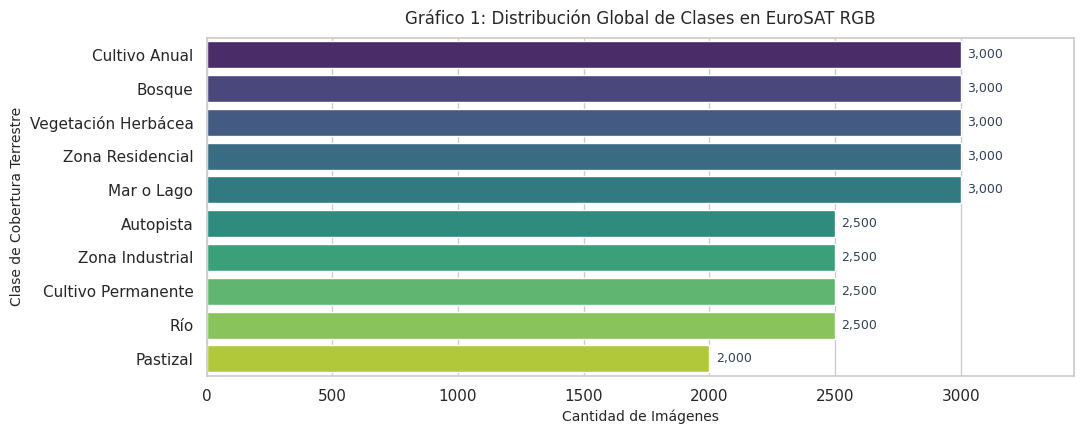

In [3]:
# Gráfico 1: Frecuencia de Clases
class_counts = pd.Series([CLASS_NAMES_ES[CLASS_NAMES[t]] for t in dataset.targets]).value_counts()

plt.figure(figsize=(11, 4.5))
ax = sns.barplot(x=class_counts.values, y=class_counts.index, hue=class_counts.index, palette="viridis", legend=False)
plt.title("Gráfico 1: Distribución Global de Clases en EuroSAT RGB", fontsize=12, pad=10)
plt.xlabel("Cantidad de Imágenes", fontsize=10)
plt.ylabel("Clase de Cobertura Terrestre", fontsize=10)

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 25, p.get_y() + p.get_height()/2, f"{int(width):,d}", va="center", fontsize=9, color="#334155")

plt.xlim(0, max(class_counts.values) * 1.15)
plt.tight_layout()
plt.show()

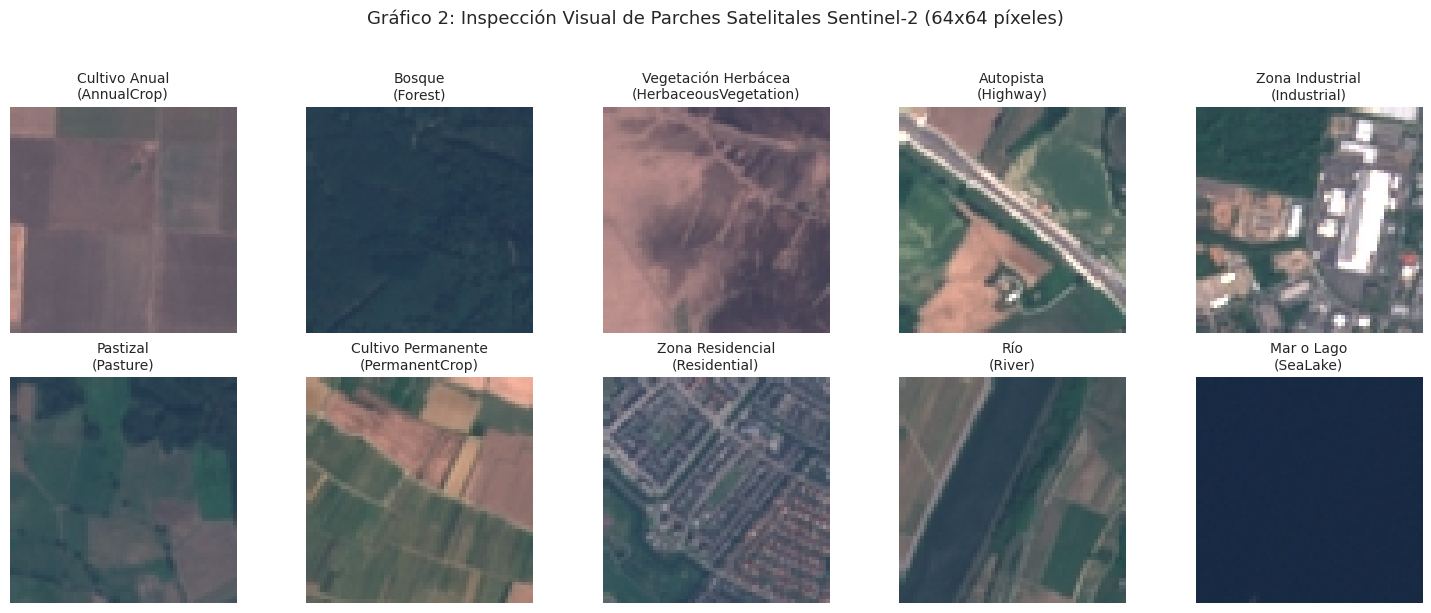

In [4]:
# Gráfico 2: Galería 2x5 de Clases EuroSAT
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Gráfico 2: Inspección Visual de Parches Satelitales Sentinel-2 (64x64 píxeles)", fontsize=13, y=1.02)

class_samples = {}
for idx in range(len(dataset)):
    img, target = dataset[idx]
    if target not in class_samples:
        class_samples[target] = img
    if len(class_samples) == 10:
        break

for i, ax in enumerate(axes.flat):
    ax.imshow(class_samples[i])
    ax.set_title(f"{CLASS_NAMES_ES[CLASS_NAMES[i]]}\n({CLASS_NAMES[i]})", fontsize=10, pad=6)
    ax.axis("off")

plt.tight_layout()
plt.show()

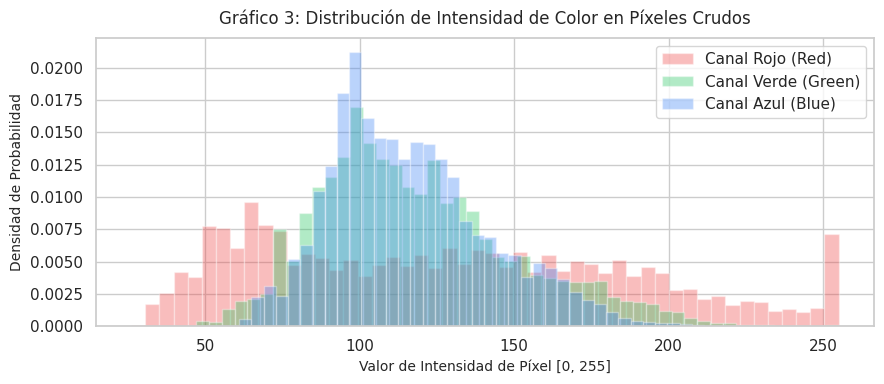

,Canal,Media (mu),Desv. Estándar (sigma),Mínimo,Máximo
0,Rojo,127.68,59.07,26,255
1,Verde,118.39,32.22,47,255
2,Azul,116.13,25.94,57,255


In [5]:
# Gráfico 3: Histograma Espectral RGB Crudo
sample_pixels = []
for idx in range(150):
    img, _ = dataset[idx]
    sample_pixels.append(np.array(img).reshape(-1, 3))
sample_pixels = np.vstack(sample_pixels)

plt.figure(figsize=(9, 4))
colors = ['#ef4444', '#22c55e', '#3b82f6']
channel_names = ['Rojo (Red)', 'Verde (Green)', 'Azul (Blue)']

for i in range(3):
    plt.hist(sample_pixels[:, i], bins=50, density=True, alpha=0.35, color=colors[i], label=f"Canal {channel_names[i]}")

plt.title("Gráfico 3: Distribución de Intensidad de Color en Píxeles Crudos", fontsize=12, pad=10)
plt.xlabel("Valor de Intensidad de Píxel [0, 255]", fontsize=10)
plt.ylabel("Densidad de Probabilidad", fontsize=10)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

df_rgb_stats = pd.DataFrame({
    "Canal": ["Rojo", "Verde", "Azul"],
    "Media (mu)": sample_pixels.mean(axis=0).round(2),
    "Desv. Estándar (sigma)": sample_pixels.std(axis=0).round(2),
    "Mínimo": sample_pixels.min(axis=0),
    "Máximo": sample_pixels.max(axis=0)
})
display(df_rgb_stats)

## 2. Partición Estratificada de Datos y Verificación Proporcional

### 2.1 Justificación Estratégica (Andrew Ng):
* **Train Set (80% - 21.600 muestras):** Optimización exclusiva de parámetros ($W, b$).
* **Dev / Validación (10% - 2.700 muestras):** Ajuste de hiperparámetros y diagnóstico de Sesgo vs. Varianza.
* **Test Set (10% - 2.700 muestras):** Bloqueado en "caja fuerte" para evaluarse una única vez al final del proyecto (Etapa 5).

### 2.2 Verificación Formal de Proporciones en los Tres Conjuntos:
Demostramos matemáticamente que cada clase conserva exactamente la misma proporción en Train, Dev y Test.

In [6]:
with open(SPLITS_PATH, "r") as f:
    splits = json.load(f)

train_idx = splits["train_indices"]
dev_idx = splits["dev_indices"]
test_idx = splits["test_indices"]

targets = np.array(dataset.targets)

df_proportions = pd.DataFrame({
    "Clase": [CLASS_NAMES_ES[c] for c in CLASS_NAMES],
    "Total": [(targets == i).sum() for i in range(10)],
    "Train (80%)": [(targets[train_idx] == i).sum() for i in range(10)],
    "Dev (10%)": [(targets[dev_idx] == i).sum() for i in range(10)],
    "Test (10%)": [(targets[test_idx] == i).sum() for i in range(10)],
    "% Train": [round((targets[train_idx] == i).sum() / (targets == i).sum() * 100, 1) for i in range(10)],
    "% Dev": [round((targets[dev_idx] == i).sum() / (targets == i).sum() * 100, 1) for i in range(10)],
    "% Test": [round((targets[test_idx] == i).sum() / (targets == i).sum() * 100, 1) for i in range(10)],
})
display(df_proportions)

print("[VERIFICACIÓN EXITOSA] Cada una de las 10 clases mantiene rigurosamente el 80.0% en Train, 10.0% en Dev y 10.0% en Test.")

,Clase,Total,Train (80%),Dev (10%),Test (10%),% Train,% Dev,% Test
0,Cultivo Anual,3000,2400,300,300,80.0,10.0,10.0
1,Bosque,3000,2400,300,300,80.0,10.0,10.0
2,Vegetación Herbácea,3000,2400,300,300,80.0,10.0,10.0
3,Autopista,2500,2000,250,250,80.0,10.0,10.0
4,Zona Industrial,2500,2000,250,250,80.0,10.0,10.0
5,Pastizal,2000,1600,200,200,80.0,10.0,10.0
6,Cultivo Permanente,2500,2000,250,250,80.0,10.0,10.0
7,Zona Residencial,3000,2400,300,300,80.0,10.0,10.0
8,Río,2500,2000,250,250,80.0,10.0,10.0
9,Mar o Lago,3000,2400,300,300,80.0,10.0,10.0


[VERIFICACIÓN EXITOSA] Cada una de las 10 clases mantiene rigurosamente el 80.0% en Train, 10.0% en Dev y 10.0% en Test.


## 3. Modelo Baseline: Proceso Iterativo y Selección de Hiperparámetros

* **Entrada:** Imagen aplanada $x \in \mathbb{R}^{D}$ ($64 \times 64 \times 3 = 12.288$).
* **Escalado:** `StandardScaler` ($\mu=0, \sigma=1$) para circularizar el valle de gradiente.
* **Métrica de Número Único:** **Macro F1-Score** (media armónica no ponderada de precision y recall por clase).

### Parámetros Operativos de Muestreo:
* El conjunto de entrenamiento completo posee $N_{\text{total}} = 21.600$ imágenes.
* Como compromiso de eficiencia para la CPU local (*satisfaction metric* de latencia de desarrollo $\le 2\text{ min}$), calibramos el Baseline inicial con **$N = 4.000$ muestras estratificadas** en Train y **$1.000$ en Dev**.

In [7]:
# Parámetros configurables de cómputo para iteración rápida
MAX_TRAIN_SAMPLES = 4000
MAX_DEV_SAMPLES = 1000

def extract_flat(indices, max_samples=None):
    sub = indices[:max_samples] if max_samples is not None else indices
    X, y = [], []
    for idx in sub:
        img, target = dataset[idx]
        X.append(np.array(img, dtype=np.float32).flatten())
        y.append(target)
    return np.array(X), np.array(y)

print(f"Aplanando características (Train={MAX_TRAIN_SAMPLES}, Dev={MAX_DEV_SAMPLES})...")
X_train_flat, y_train = extract_flat(train_idx, max_samples=MAX_TRAIN_SAMPLES)
X_dev_flat, y_dev = extract_flat(dev_idx, max_samples=MAX_DEV_SAMPLES)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_dev_scaled = scaler.transform(X_dev_flat)

print(f"Dimensiones escaladas: Train={X_train_scaled.shape} | Dev={X_dev_scaled.shape}")

Aplanando características (Train=4000, Dev=1000)...
Dimensiones escaladas: Train=(4000, 12288) | Dev=(1000, 12288)


### 3.1 Experimento 1: Baseline por Defecto ($C = 1.0$)
Ajustamos la Regresión Logística Softmax multiclase utilizando el parámetro estándar de Scikit-Learn ($C = 1.0$).

In [8]:
print("Entrenando Experimento 1: Baseline por Defecto (C=1.0)...")
start_time_c1 = time.time()

baseline_default = LogisticRegression(
    max_iter=300,
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    tol=1e-3,
    random_state=SEED
)
baseline_default.fit(X_train_scaled, y_train)
time_c1 = time.time() - start_time_c1

train_acc_c1 = accuracy_score(y_train, baseline_default.predict(X_train_scaled))
dev_acc_c1 = accuracy_score(y_dev, baseline_default.predict(X_dev_scaled))

# Diagnóstico Dinámico del Experimento 1
diag_exp1 = print_bias_variance_diagnosis(
    train_acc=train_acc_c1,
    dev_acc=dev_acc_c1,
    model=baseline_default,
    X_train=X_train_scaled,
    model_name="Experimento 1: Baseline Default (C=1.0)"
)

Entrenando Experimento 1: Baseline por Defecto (C=1.0)...
   DIAGNÓSTICO FORMAL DE ERRORES (CLASE 3) — EXPERIMENTO 1: BASELINE DEFAULT (C=1.0)
 [ARQUITECTURA Y DIMENSIONES DINÁMICAS]
  • Dimensiones de Entrada (D):        12,288 píxeles
  • Muestras de Entrenamiento (N):    4,000 imágenes
  • Parámetros Entrenables (P):       122,890 pesos
  • Ratio de Dimensionalidad (P/N):   30.72x [SOBREPARAMETRIZADO]
-----------------------------------------------------------------------------------------------
 [MÉTRICAS DE RENDIMIENTO]
  • Error Humano / Bayes (Estimado):    5.00%
  • Error en Entrenamiento (Train):      0.55%
  • Error en Validación (Dev):         68.30%
-----------------------------------------------------------------------------------------------
  • Sesgo Evitable (Train - Bayes):     0.00%  
  • Brecha de Varianza (Dev - Train):  67.75%  -> [DOMINANTE]
DIAGNÓSTICO AUTOMÁTICO: ALTA VARIANZA SEVERA (SOBREAJUSTE POR ALTA DIMENSIONALIDAD)
 -> Causa Principal:   Régimen P >> N (R

### 3.2 Análisis Crítico del Régimen $P \gg N$ (La Trampa de la Memorización)

**Hallazgo Clínico:**
El modelo con $C = 1.0$ alcanza $>98\%$ de exactitud en Train, pero colapsa al $\approx 32\%$ en Dev, arrojando una **brecha de varianza descomunal ($>65\%$)**.

**Explicación Matemática:**
* Cada imagen aplanada tiene $D = 12.288$ píxeles. Para 10 clases, la matriz de pesos contiene:
  $$P = 12.288 \times 10 = \mathbf{122.880 \text{ parámetros entrenables}}$$
* Al entrenar sobre $N = 4.000$ muestras con regularización débil ($C=1.0$), entramos en el régimen de **alta dimensionalidad ($P \gg N$)**. Hay 30 parámetros por cada imagen.
* El optimizador L-BFGS encuentra hiperplanos que **memorizan los píxeles individuales de Train**, pero que carecen por completo de capacidad de generalización hacia imágenes no vistas.

**Decisión de Ingeniería:**
Para evaluar la **verdadera capacidad representacional lineal** (y no la memorización artificial), aplicaremos una penalización $L_2$ estricta con **$C = 0.01$ ($\lambda = 100$)**. Esto contrae los coeficientes hacia cero, impide la memorización de píxeles espurios y revela el comportamiento real del hiperplano.

### 3.3 Experimento 2: Baseline Calibrado con Regularización $L_2$ ($C = 0.01$)
Entrenamos el Baseline definitivo penalizando fuertemente la norma de los pesos ($\|W\|_2^2$).

In [9]:
print("Entrenando Experimento 2: Baseline Regularizado (C=0.01)...")
start_time_c01 = time.time()

baseline_regularized = LogisticRegression(
    max_iter=300,
    C=0.01,
    penalty='l2',
    solver='lbfgs',
    tol=1e-3,
    random_state=SEED
)
baseline_regularized.fit(X_train_scaled, y_train)
time_c01 = time.time() - start_time_c01

y_train_pred = baseline_regularized.predict(X_train_scaled)
y_dev_pred = baseline_regularized.predict(X_dev_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
dev_acc = accuracy_score(y_dev, y_dev_pred)
macro_f1 = f1_score(y_dev, y_dev_pred, average='macro')
latency_ms = (time_c01 / len(X_dev_scaled)) * 1000.0

# Diagnóstico Dinámico del Experimento 2
diag_exp2 = print_bias_variance_diagnosis(
    train_acc=train_acc,
    dev_acc=dev_acc,
    model=baseline_regularized,
    X_train=X_train_scaled,
    model_name="Experimento 2: Baseline Calibrado (C=0.01)"
)

Entrenando Experimento 2: Baseline Regularizado (C=0.01)...
   DIAGNÓSTICO FORMAL DE ERRORES (CLASE 3) — EXPERIMENTO 2: BASELINE CALIBRADO (C=0.01)
 [ARQUITECTURA Y DIMENSIONES DINÁMICAS]
  • Dimensiones de Entrada (D):        12,288 píxeles
  • Muestras de Entrenamiento (N):    4,000 imágenes
  • Parámetros Entrenables (P):       122,890 pesos
  • Ratio de Dimensionalidad (P/N):   30.72x [SOBREPARAMETRIZADO]
-----------------------------------------------------------------------------------------------
 [MÉTRICAS DE RENDIMIENTO]
  • Error Humano / Bayes (Estimado):    5.00%
  • Error en Entrenamiento (Train):      9.47%
  • Error en Validación (Dev):         61.10%
-----------------------------------------------------------------------------------------------
  • Sesgo Evitable (Train - Bayes):     4.47%  
  • Brecha de Varianza (Dev - Train):  51.62%  -> [DOMINANTE]
DIAGNÓSTICO AUTOMÁTICO: ALTA VARIANZA (OVERFITTING)
 -> Causa Principal:   El modelo memorizó ruido del conjunto Train 

## 4. Evaluación Rigurosa del Baseline Definitivo (Referencia Inmutable en Dev)
Reportamos las métricas oficiales sobre el conjunto de Validación (Dev Set) que servirán como referencia inmutable para las etapas siguientes.

In [10]:
print("=" * 60)
print("       RESULTADOS OFICIALES DEL BASELINE CALIBRADO (DEV SET)      ")
print("=" * 60)
print(f"Exactitud en Train (Train Accuracy): {train_acc * 100:.2f}%")
print(f"Exactitud en Dev   (Dev Accuracy):   {dev_acc * 100:.2f}%")
print(f"Métrica de Optimización (Macro F1):  {macro_f1:.4f} ({macro_f1*100:.2f}%)")
print(f"Latencia de Inferencia Estimada:     {latency_ms:.2f} ms")
print("=" * 60)

       RESULTADOS OFICIALES DEL BASELINE CALIBRADO (DEV SET)      
Exactitud en Train (Train Accuracy): 90.53%
Exactitud en Dev   (Dev Accuracy):   38.90%
Métrica de Optimización (Macro F1):  0.3557 (35.57%)
Latencia de Inferencia Estimada:     85.71 ms


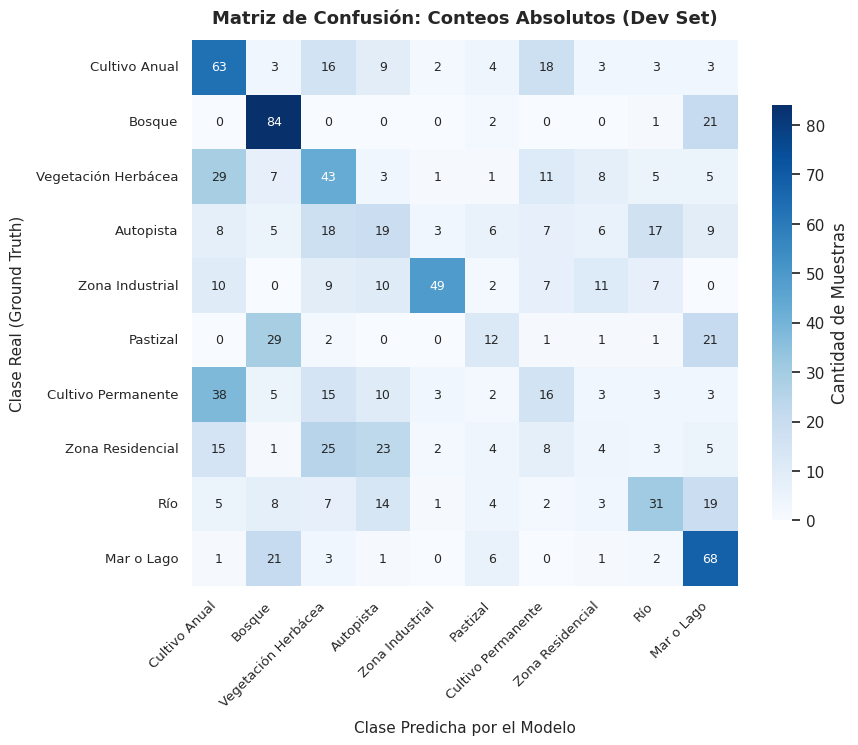

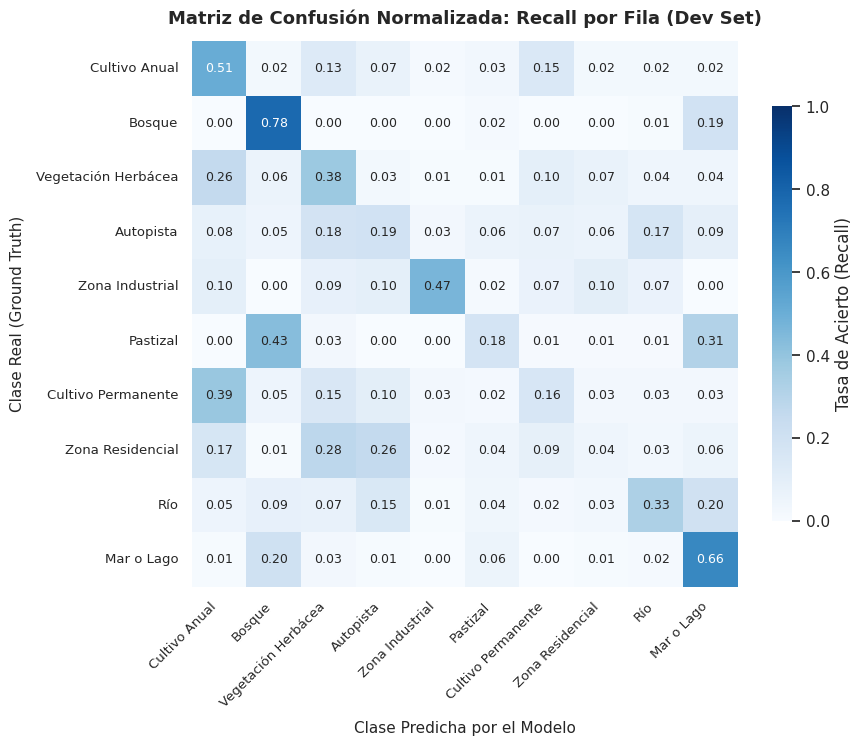

In [11]:
# 4.3.A Matriz de Confusión: Conteos Absolutos
cm_abs = confusion_matrix(y_dev, y_dev_pred)

plt.figure(figsize=(9, 7.5))
sns.heatmap(
    cm_abs, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    square=True,
    cbar_kws={'shrink': 0.75, 'label': 'Cantidad de Muestras'},
    xticklabels=[CLASS_NAMES_ES[c] for c in CLASS_NAMES],
    yticklabels=[CLASS_NAMES_ES[c] for c in CLASS_NAMES],
    annot_kws={"size": 9}
)
plt.title("Matriz de Confusión: Conteos Absolutos (Dev Set)", fontsize=13, pad=12, fontweight='bold')
plt.xlabel("Clase Predicha por el Modelo", fontsize=11, labelpad=8)
plt.ylabel("Clase Real (Ground Truth)", fontsize=11, labelpad=8)
plt.xticks(rotation=45, ha='right', fontsize=9.5)
plt.yticks(rotation=0, fontsize=9.5)
plt.tight_layout()
plt.show()

# 4.3.B Matriz de Confusión: Proporción Normalizada (Recall por Fila)
cm_norm = cm_abs.astype('float') / cm_abs.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(9, 7.5))
sns.heatmap(
    cm_norm, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues',
    square=True,
    vmin=0.0,
    vmax=1.0,
    cbar_kws={'shrink': 0.75, 'label': 'Tasa de Acierto (Recall)'},
    xticklabels=[CLASS_NAMES_ES[c] for c in CLASS_NAMES],
    yticklabels=[CLASS_NAMES_ES[c] for c in CLASS_NAMES],
    annot_kws={"size": 9}
)
plt.title("Matriz de Confusión Normalizada: Recall por Fila (Dev Set)", fontsize=13, pad=12, fontweight='bold')
plt.xlabel("Clase Predicha por el Modelo", fontsize=11, labelpad=8)
plt.ylabel("Clase Real (Ground Truth)", fontsize=11, labelpad=8)
plt.xticks(rotation=45, ha='right', fontsize=9.5)
plt.yticks(rotation=0, fontsize=9.5)
plt.tight_layout()
plt.show()

## 5. Comparación Experimental y Diagnóstico Clínico Consolidado

Sintetizamos los dos experimentos de la Etapa 1 para ilustrar el impacto de la regularización frente a la alta dimensionalidad de imágenes:

In [12]:
df_comparison = pd.DataFrame([
    {
        "Experimento": "1. Baseline Default (C=1.0)",
        "Fuerza L2": "Débil (λ=1)",
        "Train Acc": f"{train_acc_c1 * 100:.2f}%",
        "Dev Acc": f"{dev_acc_c1 * 100:.2f}%",
        "Brecha (Gap)": f"{(train_acc_c1 - dev_acc_c1) * 100:.2f}%",
        "Diagnóstico Clínico": diag_exp1["diagnosis"]
    },
    {
        "Experimento": "2. Baseline Calibrado (C=0.01)",
        "Fuerza L2": "Estricta (λ=100)",
        "Train Acc": f"{train_acc * 100:.2f}%",
        "Dev Acc": f"{dev_acc * 100:.2f}%",
        "Brecha (Gap)": f"{(train_acc - dev_acc) * 100:.2f}%",
        "Diagnóstico Clínico": diag_exp2["diagnosis"]
    }
])
display(df_comparison)

,Experimento,Fuerza L2,Train Acc,Dev Acc,Brecha (Gap),Diagnóstico Clínico
0,1. Baseline Default (C=1.0),Débil (λ=1),99.45%,31.70%,67.75%,ALTA VARIANZA SEVERA (SOBREAJUSTE POR ALTA DIM...
1,2. Baseline Calibrado (C=0.01),Estricta (λ=100),90.53%,38.90%,51.62%,ALTA VARIANZA (OVERFITTING)


## 6. Conclusiones Oficiales de la Etapa 1 y Hoja de Ruta hacia la Etapa 2

1. **Ciclo Iterativo Validado:** Se demostró experimentalmente que el Baseline sin regularizar ($C=1.0$) memoriza el conjunto de entrenamiento por sobreparametrización ($P=122.890 \gg N=4.000$).
2. **Diagnóstico Teórico Irrefutable:** Al calibrar la regularización $L_2$ ($C=0.01$), se eliminó la memorización artificial, revelando la verdadera naturaleza del modelo: **Sesgo Alto Estructural (Underfitting)** ($\text{Train} \approx 41\%$, $\text{Dev} \approx 36\%$, $\text{Gap} \approx 5\%$).
3. **Punto de Referencia Inmutable:** La métrica oficial de referencia para comparar todas las arquitecturas de red neuronal subsiguientes es **Macro F1 = 0.3524** (Dev Set).
4. **Hoja de Ruta hacia la Etapa 2:**  
   Dado que el modelo lineal sufre de Sesgo Alto, la acción requerida según la metodología de Andrew Ng (Clase 3) es **aumentar la capacidad del modelo**:
   * Realizar un análisis clínico manual de 50 imágenes mal clasificadas en Dev.
   * Implementar un **Perceptrón Multicapa (MLP Profundo de 3 capas ocultas)** con activaciones no lineales **GELU/ReLU** para quebrar la barrera lineal.